<a href="https://colab.research.google.com/github/joaohppenha/govspendertest/blob/main/Agrupamento_segmentacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentação de Perfis de Consumo com K-Means



Este notebook tem como objetivo agrupar os CPFs da base de dados de gastos públicos por similaridade de comportamento de consumo. Para isso, utilizaremos o algoritmo de aprendizado de máquina não supervisionado **K-Means**.

### O que será feito neste notebook:
1. **Importação e Autenticação:** Conexão segura com o GitHub utilizando um token armazenado nos *Secrets* do Google Colab para baixar a base em formato `.parquet`.
2. **Seleção de Variáveis:** Filtragem das colunas de comportamento geral de gastos:
   - `VOLUME_TOTAL_LOG_SCALED`: Volume total gasto (normalizado).
   - `TICKET_MEDIO_LOG_SCALED`: Valor médio por transação (normalizado).
3. **Treinamento do Modelo (K-Means):** O algoritmo vai rodar em toda a base e aproximar os CPFs que possuem números parecidos nessas duas métricas, dividindo-os em 3 grupos (clusters).
4. **Padronização Lógica das Etiquetas:** Reorganização automática dos grupos para garantir uma interpretação intuitiva:
   - **`0`**: Grupo que gasta pouco
   - **`1`**: Grupo de gastos moderados
   - **`2`**: Grupo que gasta mais (gasta muito)
5. **Resultado Prático:** Criação da nova coluna `cluster_kmeans` na base de dados, categorizando cada linha, seguida de um gráfico de dispersão para visualização dos perfis formados.

**Instalação e Importação de Bibliotecas**

In [1]:
# Instalação das bibliotecas necessárias para leitura de arquivos parquet e modelagem
!pip install -q pyarrow fastparquet requests scikit-learn seaborn matplotlib

import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from google.colab import userdata

print("Bibliotecas importadas com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.3 MB/s eta 0:00:00
Bibliotecas importadas com sucesso!


**Download da Base**

In [3]:
# Resgatando o token dos Secrets do Colab de forma segura
try:
    github_token = userdata.get('Githubtolken')
except Exception as e:
    github_token = None
    print("Aviso: Token não encontrado nos Secrets. Tentando acesso público...")

# URL no formato raw fornecida
url = "https://github.com/joaohppenha/govspendertest/raw/refs/heads/main/gold/camada_gold.parquet"

headers = {}
if github_token:
    headers["Authorization"] = f"token {github_token}"

print("Baixando a base de dados do GitHub...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    # Leitura do arquivo parquet diretamente em memória
    df = pd.read_parquet(io.BytesIO(response.content))
    print(f"Sucesso! Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")
else:
    raise Exception(f"Erro ao baixar o arquivo. Status code: {response.status_code}. Verifique se o secret 'GITHUB_TOKEN' está configurado corretamente.")

# Exibindo as primeiras linhas para validação
display(df[['HASH_CPF_PORTADOR', 'VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].head())

Baixando a base de dados do GitHub...
Sucesso! Base carregada com 2810 linhas e 19 colunas.


,HASH_CPF_PORTADOR,VOLUME_TOTAL_LOG_SCALED,TICKET_MEDIO_LOG_SCALED
0,000edd7142e0a18d234c19e52222ad8fa27230eab85cca...,-1.458633,-2.201331
1,0044817ad2e2f83f9f53d70c07731412d0c4880b13d7aa...,-0.597081,-1.356829
2,0048938b883fdd9eb27e4021a1e0e9e87d389933382be1...,-0.700652,0.013905
3,009d7a3b99570625c93525120c3905601245c6142d5268...,-0.101876,-0.175712
4,00b8a6cc4636fded01e21620f7e2a04c427d472a0db3f3...,1.004440,0.850489


**Treinamento do K-Means e Classificação dos Perfis**

In [4]:
# 1. Selecionando as colunas para o comportamento geral de gastos
X = df[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].values

# 2. Executando o treinamento do K-Means (definindo 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_temp'] = kmeans.fit_predict(X)

# 3. Padronizando as etiquetas (Labels) de forma lógica com base no volume médio
# 0 = Gasta pouco, 1 = Gastos moderados, 2 = Gasta muito
cluster_ordem = df.groupby('cluster_temp')['VOLUME_TOTAL_LOG_SCALED'].mean().sort_values().index
mapeamento = {cluster_ordem[0]: 0, cluster_ordem[1]: 1, cluster_ordem[2]: 2}

df['cluster_kmeans'] = df['cluster_temp'].map(mapeamento)
df.drop(columns=['cluster_temp'], inplace=True)

# 4. Exibindo a distribuição final dos CPFs por perfil
print("Distribuição dos CPFs por Perfil de Consumo:")
print(df['cluster_kmeans'].value_counts().sort_index())

Distribuição dos CPFs por Perfil de Consumo:
cluster_kmeans
0     423
1    1377
2    1010
Name: count, dtype: int64


**Visualização Gráfica dos Grupos**

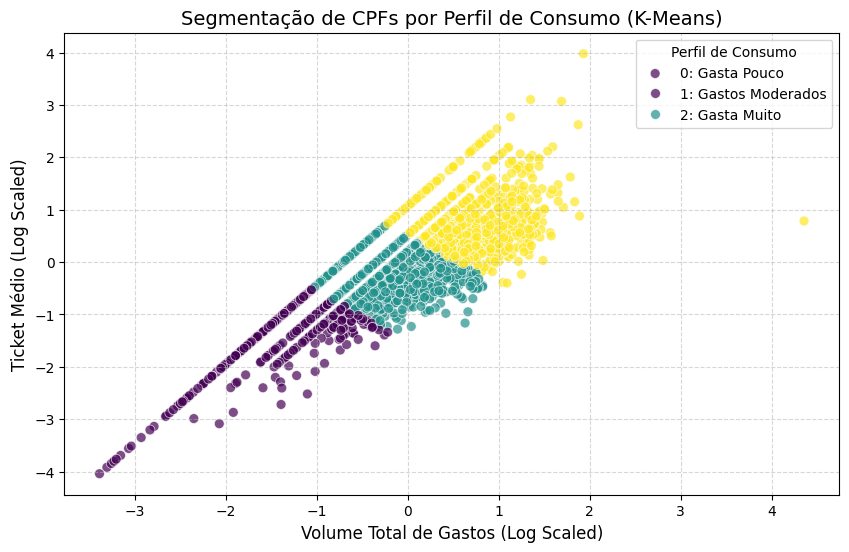

In [5]:
# Plotando o gráfico de dispersão dos perfis de consumo
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG_SCALED',
    y='TICKET_MEDIO_LOG_SCALED',
    hue='cluster_kmeans',
    palette='viridis',
    alpha=0.7,
    s=50
)

plt.title('Segmentação de CPFs por Perfil de Consumo (K-Means)', fontsize=14)
plt.xlabel('Volume Total de Gastos (Log Scaled)', fontsize=12)
plt.ylabel('Ticket Médio (Log Scaled)', fontsize=12)
plt.legend(title='Perfil de Consumo', labels=['0: Gasta Pouco', '1: Gastos Moderados', '2: Gasta Muito'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Explicação das Métricas**

### Avaliação da Qualidade dos Grupos (Métricas)


Para garantir que os CPFs foram bem separados, podemos calcular métricas de validação de clusters:
1. **Inércia (Within-Cluster Sum of Squares):** Mede o quão compactos são os clusters (quanto menor, mais unidos os pontos são dentro do mesmo grupo).
2. **Coeficiente de Silhueta (Silhouette Score):** Mede o quão bem separados os grupos estão uns dos outros. Varia de `-1` a `1`:
   - Próximo de `1`: Os grupos estão bem definidos e separados.
   - Próximo de `0`: Há sobreposição entre os grupos.
   - Negativo: Os pontos podem estar no grupo errado.

---



Utilizamos o Coeficiente de Silhueta para medir a separação dos clusters e a Inércia para garantir a compactação interna de cada grupo de gasto. K-Means agrupou os CPFs geometricamente com base no volume total e no ticket médio normalizados, e depois ordenamos as etiquetas de 0 a 2 em ordem crescente de consumo.



In [6]:
from sklearn.metrics import silhouette_score

# 1. Inércia (WSS) - quanto menor, mais coeso é o agrupamento
inercia = kmeans.inertia_
print(f"Inércia do Modelo (Compactação): {inercia:.2f}")

# 2. Coeficiente de Silhueta - avalia a separação entre os 3 perfis
score_silhueta = silhouette_score(X, df['cluster_kmeans'])
print(f"Coeficiente de Silhueta Médio: {score_silhueta:.4f}")

# Estatísticas descritivas de cada grupo para justificar as métricas na prática
print("\nMédia de Gastos e Ticket por Perfil:")
resumo_clusters = df.groupby('cluster_kmeans')[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].agg(['mean', 'count'])
display(resumo_clusters)

Inércia do Modelo (Compactação): 1145.64
Coeficiente de Silhueta Médio: 0.4126

Média de Gastos e Ticket por Perfil:


VOLUME_TOTAL_LOG_SCALED       TICKET_MEDIO_LOG_SCALED      
                                  mean count                    mean count
cluster_kmeans                                                            
0                            -1.313684   423               -1.375282   423
1                            -0.182750  1377               -0.202661  1377
2                             0.649219  1010                0.751986  1010